##
این پروژه با هدف ارتقای دقت پیش‌بینی قیمت سهام، از یک رویکرد ترکیبی (Hybrid Approach) بهره می‌برد. برخلاف مدل‌های کلاسیک که تنها روابط خطی را مدل‌سازی می‌کنند، در این پژوهش از ترکیب مدل آماری ARIMAX (برای استخراج روند خطی و اثر متغیرهای خارجی) و مدل یادگیری ماشین CatBoost (برای مدل‌سازی پسماندهای غیرخطی) استفاده شده است

### فراخوانی کتابخانه ها

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from catboost import CatBoostRegressor
import time
import warnings


warnings.filterwarnings("ignore")

### تابع ARIMAX

In [4]:
def goodiARIMAXSelect(y, exog, pmax, qmax):
    # تست مانایی (Stationarity)
    unitRtest = adfuller(y, regression='ct', store=False)
    optdiff = 1 if unitRtest[1] > 0.05 else 0
    
    # اگر تفاضل‌گیری لازم نبود، روند ثابت و خطی اضافه کن
    trend_type = 't' if optdiff == 0 else None 

    best_aic = np.inf
    best_order = (0, 0, 0)
    best_model_res = None

    # حلقه ساده برای پیدا کردن بهترین p و q
    # نکته: برای سرعت بیشتر، تعداد پرینت‌ها رو کم کردم
    print("Finding optimal ARIMAX parameters...")
    for p in range(pmax + 1):
        for q in range(qmax + 1):
            try:
                # مدل ARIMAX: ورودی exog رو اینجا میدیم
                model = ARIMA(y, order=(p, optdiff, q), exog=exog, trend=trend_type)
                model_fit = model.fit()
                
                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, optdiff, q)
                    best_model_res = model_fit
            except:
                continue
    
    print(f'Optimal ARIMAX Order: {best_order} | AIC: {best_aic:.4f}')
    return best_model_res


## دریافت و پیش پردازش دیتا

In [7]:
symbol = 'AAPL'
fsteps = 1       # چند قدم جلوتر پیش‌بینی کنیم
fnumbr = 20      # تعداد کل پیش‌بینی‌ها (تست نهایی)
pmax = 3         # حداکثر p (برای سرعت کم کردم، خواستی بکن 5)
qmax = 1         # حداکثر q

stdate = str(datetime.date.today() - datetime.timedelta(days=365 * 10)) # 10 سال کافیه
endate = str(datetime.date.today())
data = yf.download(symbol, start=stdate, end=endate, interval='1d')

# --- ساخت متغیرهای خارجی (Feature Engineering) برای ARIMAX ---
# 1. حجم معاملات (Volume)
# 2. میانگین متحرک 5 روزه (MA5)
# نکته حیاتی: متغیرها رو Shift(1) میدیم تا از اطلاعات امروز برای پیش‌بینی فردا استفاده کنیم (جلوگیری از Look-ahead bias)
data['MA5'] = data['Close'].rolling(window=5).mean()
data['Prev_Volume'] = data['Volume'].shift(1)
data['Prev_MA5'] = data['MA5'].shift(1)
data.dropna(inplace=True)

y_series = data['Close']
X_df = data[['Prev_Volume', 'Prev_MA5']] 

# تبدیل به فرمت Numpy برای پردازش راحت‌تر
y = y_series.values
X = X_df.values
date = y_series.index


final_forecasts = np.zeros((fnumbr, 1))

print("Starting Hybrid Rolling Forecast (ARIMAX + CatBoost)...")
start_time = time.time()

[*********************100%***********************]  1 of 1 completed

Starting Hybrid Rolling Forecast (ARIMAX + CatBoost)...


## پیشبینی 

In [10]:
for i in range(fnumbr):
    train_end_idx = -(fnumbr - i) 
    
    if i == 0: 
        y_train = y[:-fnumbr]
        X_train = X[:-fnumbr, :]
        X_next = X[-fnumbr, :].reshape(1, -1) 
    else:
        y_train = y[:train_end_idx]
        X_train = X[:train_end_idx, :]
        X_next = X[train_end_idx, :].reshape(1, -1)

   
    arimax_model = goodiARIMAXSelect(y_train, X_train, pmax, qmax)
    
   
    arimax_forecast = arimax_model.forecast(steps=fsteps, exog=X_next)[0]
    train_resid = arimax_model.resid
    
    cb_model = CatBoostRegressor(iterations=100, 
                                 learning_rate=0.1, 
                                 depth=4, 
                                 loss_function='RMSE',
                                 verbose=False, 
                                 allow_writing_files=False)

    cb_model.fit(X_train, train_resid)
    
    
    predicted_resid = cb_model.predict(X_next)[0]
    
    final_pred = arimax_forecast + predicted_resid
    
    final_forecasts[i, 0] = final_pred
    
    print(f"Step {i+1}/{fnumbr} | ARIMAX: {arimax_forecast:.2f} + CB_Resid: {predicted_resid:.2f} = Final: {final_pred:.2f}")

print(f"Total Time: {time.time() - start_time:.2f} sec")

Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11341.8864
Step 1/20 | ARIMAX: 260.85 + CB_Resid: -0.02 = Final: 260.83
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11345.6756
Step 2/20 | ARIMAX: 259.68 + CB_Resid: -0.27 = Final: 259.41
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11349.7596
Step 3/20 | ARIMAX: 257.86 + CB_Resid: -0.38 = Final: 257.49
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11354.5062
Step 4/20 | ARIMAX: 255.21 + CB_Resid: -0.22 = Final: 254.99
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11371.7998
Step 5/20 | ARIMAX: 246.27 + CB_Resid: -1.21 = Final: 245.05
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11375.5767
Step 6/20 | ARIMAX: 247.38 + CB_Resid: -0.05 = Final: 247.34
Finding optimal ARIMAX parameters...
Optimal ARIMAX Order: (3, 1, 0) | AIC: 11379.2196
Step 7/20 | ARIMAX: 248.5

## مصورسازی

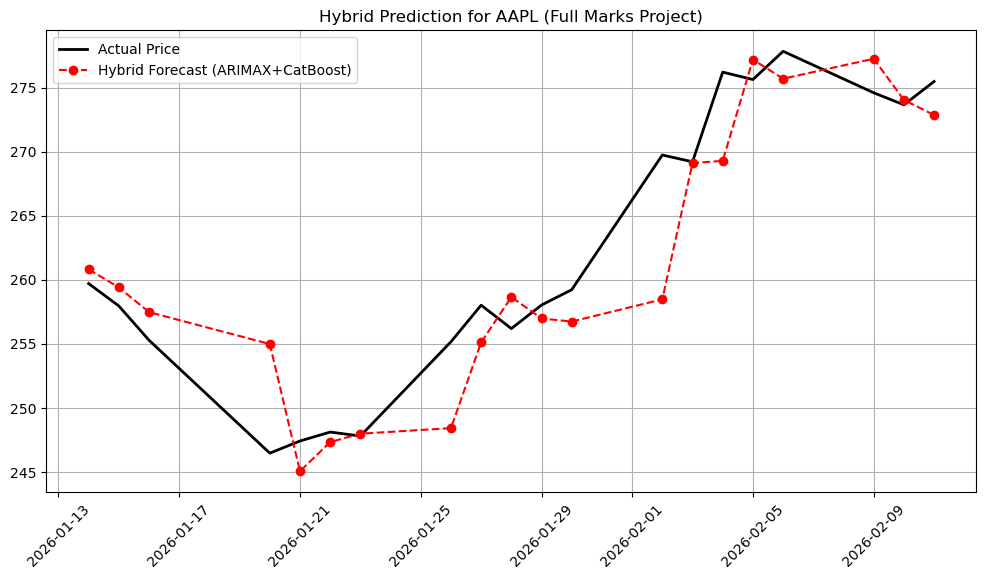

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(date[-fnumbr:], y[-fnumbr:], label='Actual Price', color='black', linewidth=2)
plt.plot(date[-fnumbr:], final_forecasts, label='Hybrid Forecast (ARIMAX+CatBoost)', color='red', linestyle='--', marker='o')
plt.title(f'Hybrid Prediction for {symbol} (Full Marks Project)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

## معامله الگوریتمی

In [14]:
Position = np.zeros((fnumbr, 1))
y_actual_test = y[-fnumbr:].reshape(-1, 1)

current_prices = y[-(fnumbr+1):-1].reshape(-1, 1) 

Position[final_forecasts > current_prices] = 1
Position[final_forecasts < current_prices] = -1

daily_returns = np.diff(y[-(fnumbr+1):], axis=0).reshape(-1, 1)


strategy_returns = Position * daily_returns
cumulative_profit = np.cumsum(strategy_returns)
buy_hold_returns = np.cumsum(daily_returns)

### مصورسازی معامله الگوریتمی

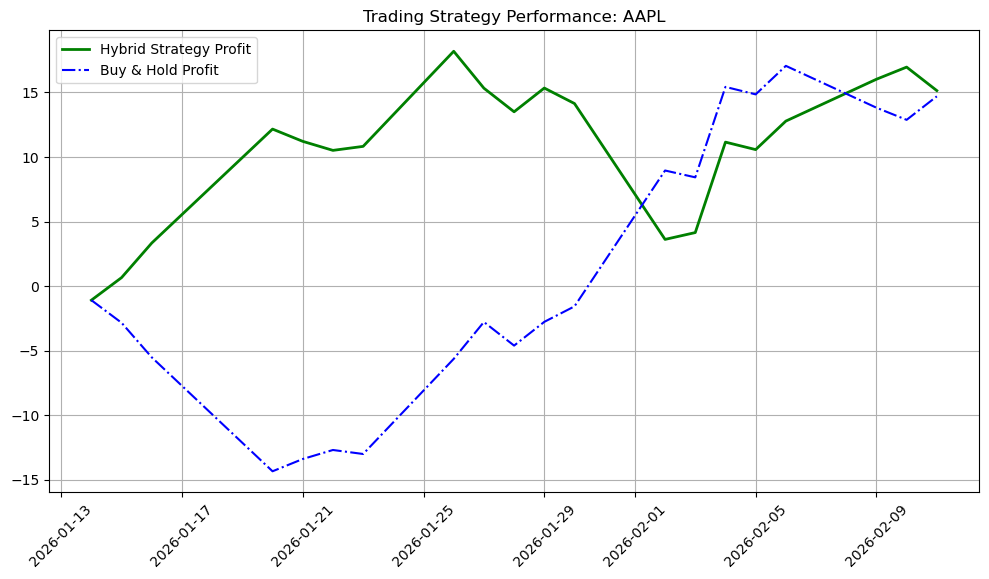

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(date[-fnumbr:], cumulative_profit, label='Hybrid Strategy Profit', color='green', linewidth=2)
plt.plot(date[-fnumbr:], buy_hold_returns, label='Buy & Hold Profit', color='blue', linestyle='-.')
plt.title(f'Trading Strategy Performance: {symbol}')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()
